# Tugas Praktikum Modul 05: Pipeline Klasifikasi Teks dengan SVM & Naïve Bayes
**Mata Kuliah:** Machine Learning  
**Topik:** Klasifikasi Sentimen Komentar Konten Dakwah Media Sosial Pesantren  
**Algoritma:** Support Vector Machine (SVM) & Naïve Bayes (*from scratch* dan `scikit-learn`)  
**Penulis:** Arifian Ilham Nur Riandana (`arifianilhamnrr`)  
**Repository GitHub:** `pertemuan5-tugas-svm-naivebayes`  

---

### Skenario Tugas:
Tim media dakwah pesantren menerima ratusan komentar setiap harinya di platform media sosial (YouTube, Instagram, TikTok). Untuk meningkatkan efektivitas dakwah dan merespons pertanyaan umat secara cepat, dibangun sistem klasifikasi cerdas 3 kategori:
1. **Positif:** Apresiasi, doa, dan testimoni kebermanfaatan konten.
2. **Netral:** Pertanyaan administratif, jadwal kajian, rujukan kitab, dan info panitia.
3. **Negatif:** Kritik terhadap substansi, komplain teknis audio-visual, ujaran ketidakpuasan, atau retorika provokatif.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

print("Environment dan library berhasil diimpor dengan sukses!")

Environment dan library berhasil diimpor dengan sukses!


## Bagian 1: Dataset & Exploratory Data Analysis (EDA)
Dataset teks dibangun secara spesifik merepresentasikan dinamika komentar konten dakwah pesantren sebanyak **75 data berimbang (25 Positif, 25 Netral, 25 Negatif)**.


In [2]:
# 1. Konstruksi Dataset Sentimen Komentar Dakwah
raw_data = [
    # Positif (25)
    ('Alhamdulillah ceramahnya sangat bermanfaat dan menyejukkan hati', 'positif'),
    ('Materi fiqih kali ini sangat mencerahkan dan mudah dipahami', 'positif'),
    ('Terima kasih banyak ustadz atas ilmu yang sangat berharga ini', 'positif'),
    ('Penyampaian dakwahnya sangat santun penuh hikmah dan keteladanan', 'positif'),
    ('Semoga Allah senantiasa melimpahkan berkah dan kesehatan untuk ustadz', 'positif'),
    ('Kajian terbaik yang pernah saya simak pembahasannya sangat mendalam', 'positif'),
    ('Penjelasannya sangat jelas langsung mengena pada persoalan sehari-hari', 'positif'),
    ('Sangat menginspirasi semoga kita semua istiqomah dalam kebaikan', 'positif'),
    ('Kajian rutin yang selalu saya tunggu-tunggu pembawaannya tenang', 'positif'),
    ('Masya Allah penyampaian dalilnya sangat kuat dan terstruktur', 'positif'),
    ('Sangat bersyukur bisa menyimak kajian ini menambah kecintaan pada sunnah', 'positif'),
    ('Ilmu yang sangat aplikatif untuk diterapkan dalam mendidik anak di rumah', 'positif'),
    ('Ustadz mampu merangkum tema yang rumit menjadi sangat sederhana', 'positif'),
    ('Bahasanya mudah dicerna untuk orang awam seperti saya berkah selalu', 'positif'),
    ('Nasihatnya menyentuh sanubari mengingatkan kembali tentang tujuan hidup', 'positif'),
    ('Konten dakwah yang sangat berkualitas patut disebarluaskan ke jamaah', 'positif'),
    ('Jazakallah khairan ustadz paparannya membuka wawasan keislaman saya', 'positif'),
    ('Sangat suka dengan analogi praktis yang dipakai ustadz dalam ceramah', 'positif'),
    ('Penjelasan mengenai adab dan akhlak ini sangat relevan untuk zaman modern', 'positif'),
    ('Kajian yang sangat menenangkan di tengah kesibukan duniawi', 'positif'),
    ('Alhamdulillah setiap mendengarkan kajian ustadz hati terasa damai', 'positif'),
    ('Penjelasan kitab kuningnya sangat bernas dan penuh rujukan muktabar', 'positif'),
    ('Subhanallah tausiyah yang sarat dengan pesan moral dan nilai luhur', 'positif'),
    ('Penyampaian tausiyahnya sangat bersahabat tidak menghakimi jamaah', 'positif'),
    ('Semoga majelis ilmu ini terus berkembang dan menebar kebaikan luas', 'positif'),

    # Netral (25)
    ('Apakah kajian berikutnya akan diadakan secara luring atau daring', 'netral'),
    ('Mohon info judul kitab rujukan yang digunakan pada kajian malam ini', 'netral'),
    ('Kapan jadwal halaqah tafsir pekan depan dimulai ustadz', 'netral'),
    ('Berapa lama durasi rekaman video kajian ini secara keseluruhan', 'netral'),
    ('Apakah materi salindia presentasi ini bisa diunduh oleh jamaah', 'netral'),
    ('Dimana lokasi masjid tempat kajian rutin ini diselenggarakan', 'netral'),
    ('Mohon izin bertanya nomor kontak panitia kajian untuk konfirmasi hadir', 'netral'),
    ('Apakah ada siaran ulang di platform podcast atau audio streaming', 'netral'),
    ('Pada menit ke berapa tadi pembahasan tentang hukum jual beli online', 'netral'),
    ('Apakah kajian ini terbuka untuk umum atau khusus santri internal', 'netral'),
    ('Apakah tersedia tautan pendaftaran untuk menghadiri seminar sabtu besok', 'netral'),
    ('Kajian hari ini dimulai tepat pukul berapa ustadz mohon konfirmasi', 'netral'),
    ('Kitab hadis apa yang akan dibahas pada pertemuan bulan depan', 'netral'),
    ('Apakah ada grup telegram resmi untuk informasi jadwal pengajian', 'netral'),
    ('Mohon informasi apakah kajian ini masuk dalam silabus kurikulum pondok', 'netral'),
    ('Siapa nama narasumber tamu yang mendampingi ustadz pada sesi tadi', 'netral'),
    ('Berapa nomor rekening panitia pengadaan wakaf mushaf pesantren', 'netral'),
    ('Apakah pembahasan tema ini akan dilanjutkan pada bab berikutnya pekan depan', 'netral'),
    ('Tolong sematkan tautan kuesioner evaluasi acara di kolom deskripsi video', 'netral'),
    ('Apakah sesi tanya jawab dibuka untuk jamaah yang menyimak secara live', 'netral'),
    ('Buku rujukan ustadz tadi bisa dibeli di toko kitab mana ya', 'netral'),
    ('Kajian ini direkam pada hari apa dan tanggal berapa panitia', 'netral'),
    ('Apakah kajian hadis arbain ini diadakan setiap hari selasa pagi', 'netral'),
    ('Bagaimana cara mengajukan pertanyaan tertulis untuk sesi pekan depan', 'netral'),
    ('Berapa kapasitas ruangan aula untuk jamaah yang ingin hadir langsung', 'netral'),

    # Negatif (25)
    ('Ceramahnya sangat membosankan dan durasinya terlalu panjang', 'negatif'),
    ('Materi yang disampaikan melenceng jauh dari judul tema yang diumumkan', 'negatif'),
    ('Kualitas audionya sangat buruk berdengung dan suara ustadz tidak jelas', 'negatif'),
    ('Penyampaian ceramahnya terlalu kasar dan sering menyindir kelompok lain', 'negatif'),
    ('Saya sangat kecewa materinya terlalu dangkal dan tidak berbobot', 'negatif'),
    ('Terlalu banyak iklan dan basa-basi pembahasan intinya sangat sedikit', 'negatif'),
    ('Ustadz terlalu emosional dalam menyampaikan materi kajian kali ini', 'negatif'),
    ('Penjelasannya sangat membingungkan tidak ada kesimpulan yang runtut', 'negatif'),
    ('Kajiannya membosankan isinya hanya menyalahkan pandangan orang lain', 'negatif'),
    ('Videonya patah-patah dan pencahayaan studio sangat gelap tidak nyaman', 'negatif'),
    ('Materinya tidak relevan sama sekali dengan problematika umat masa kini', 'negatif'),
    ('Penyampaiannya berbelit-belit membuat jamaah mengantuk dan jenuh', 'negatif'),
    ('Argumen yang disampaikan sangat lemah dan kurang didukung rujukan kuat', 'negatif'),
    ('Sangat disayangkan kajian ini memicu kegaduhan dan perdebatan kusir', 'negatif'),
    ('Retorikanya provokatif dan cenderung menyudutkan madzhab tertentu', 'negatif'),
    ('Penjelasannya terburu-buru seperti mengejar waktu tanpa elaborasi', 'negatif'),
    ('Moderator tidak mampu mengatur sesi tanya jawab acaranya jadi kacau', 'negatif'),
    ('Isi ceramahnya terlalu teoritis dan mustahil diterapkan dalam praktek', 'negatif'),
    ('Kritik ustadz terhadap ormas lain sangat tidak pantas dan niradab', 'negatif'),
    ('Saya tidak setuju dengan fatwa yang disampaikan tanpa dasar dalil shahih', 'negatif'),
    ('Penyampaian ustadz kali ini terasa monoton dan kurang persiapan matang', 'negatif'),
    ('Mikrofon ustadz kresek-kresek sangat mengganggu kenyamanan menyimak', 'negatif'),
    ('Kajian ini tidak mendidik malah memperkeruh ukhuwah antar jamaah', 'negatif'),
    ('Materi disampaikan dengan nada tinggi membuat suasana terasa tegang', 'negatif'),
    ('Sangat mengecewakan tidak ada hal baru yang bisa dipelajari dari video ini', 'negatif')
]

df = pd.DataFrame(raw_data, columns=['komentar', 'sentimen'])
df.to_csv('dataset_komentar_dakwah.csv', index=False)

print(f"Total baris data : {len(df)}")
print(f"Distribusi kelas :\n{df['sentimen'].value_counts()}")
print(df.head(6))

Total baris data : 75
Distribusi kelas :
sentimen
positif    25
netral     25
negatif    25
Name: count, dtype: int64
                                            komentar sentimen
0  Alhamdulillah ceramahnya sangat bermanfaat dan...  positif
1  Materi fiqih kali ini sangat mencerahkan dan m...  positif
2  Terima kasih banyak ustadz atas ilmu yang sang...  positif
3  Penyampaian dakwahnya sangat santun penuh hikm...  positif
4  Semoga Allah senantiasa melimpahkan berkah dan...  positif
5  Kajian terbaik yang pernah saya simak pembahas...  positif


## Bagian 2: Text Preprocessing & Visualisasi EDA
Tahapan Preprocessing teks:
1. **Case Folding:** Mengubah seluruh karakter menjadi huruf kecil (*lowercase*).
2. **Regex Cleaning:** Menghilangkan tanda baca, karakter non-alfabetik, dan spasi berlebih.
3. **Stopword Removal:** Menghapus kata umum Bahasa Indonesia yang tidak membawa nilai sentimen informatif.


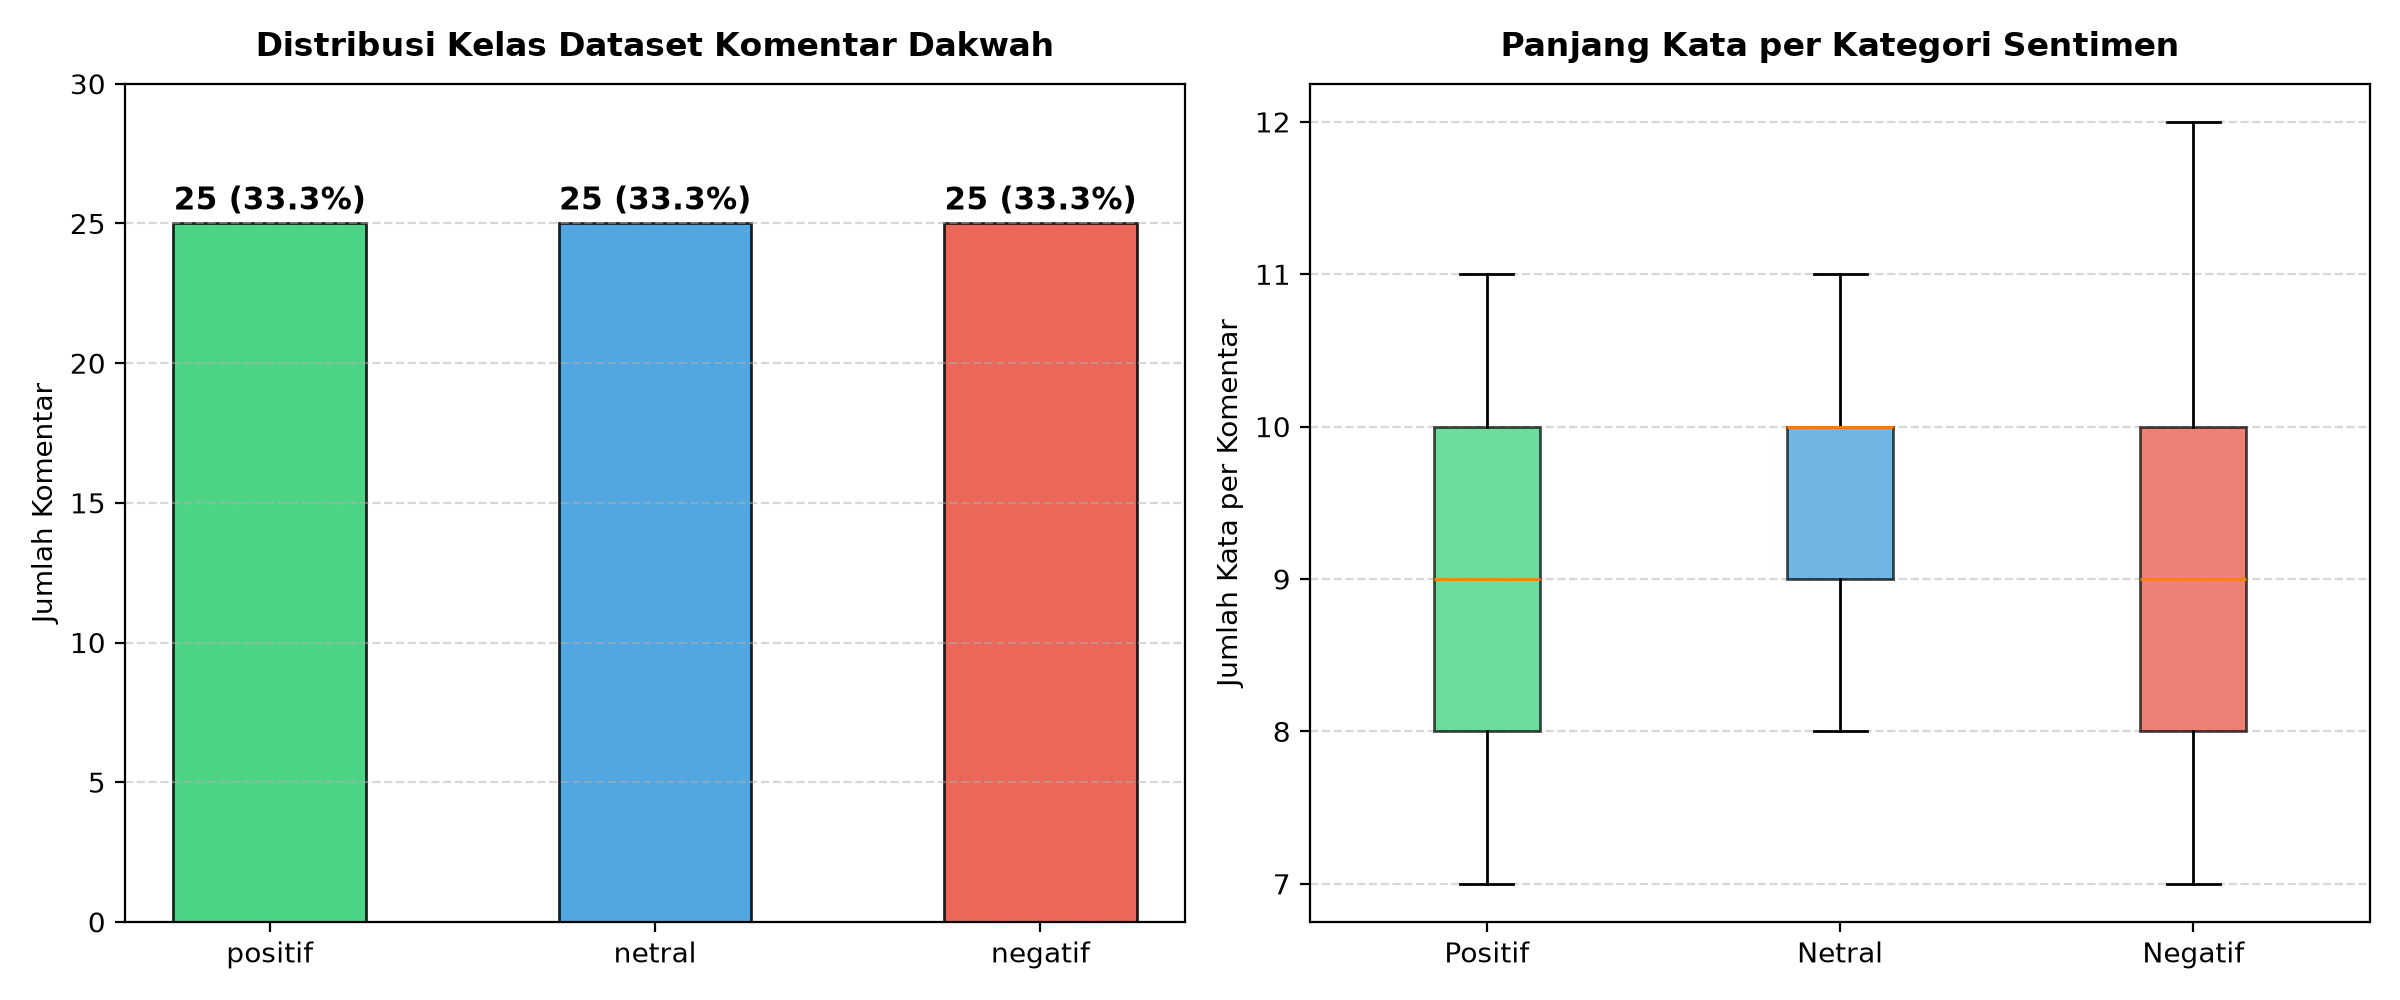

In [3]:
# Stopwords Bahasa Indonesia
STOPWORDS_ID = {
    'yang', 'di', 'dan', 'ini', 'itu', 'untuk', 'pada', 'dengan', 'dari', 'ke',
    'karena', 'oleh', 'akan', 'adalah', 'ada', 'saya', 'kami', 'kita', 'anda',
    'dia', 'mereka', 'sudah', 'telah', 'bisa', 'dapat', 'saat', 'ketika', 'dalam',
    'secara', 'atas', 'hanya', 'saja', 'atau', 'juga', 'seperti', 'terhadap',
    'kembali', 'antara', 'para', 'semua', 'setiap', 'kali', 'lagi', 'pun', 'tentang',
    'menjadi', 'sebagai', 'banyak', 'lebih', 'masih', 'agar', 'supaya', 'lalu',
    'kemudian', 'namun', 'tetapi', 'melainkan', 'sehingga', 'ia', 'jika', 'bila',
    'kalau', 'maka', 'tentu', 'serta', 'suatu', 'hal', 'pula', 'ya'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_ID and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['komentar'].apply(clean_text)
df['word_count'] = df['komentar'].apply(lambda x: len(x.split()))
df['char_count'] = df['komentar'].apply(len)

# Visualisasi Distribusi Kelas & Panjang Kata
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
classes = ['positif', 'netral', 'negatif']
counts = [sum(df['sentimen'] == c) for c in classes]
colors = ['#2ecc71', '#3498db', '#e74c3c']

ax[0].bar(classes, counts, color=colors, edgecolor='black', width=0.5, alpha=0.85)
for i, v in enumerate(counts):
    ax[0].text(i, v + 0.5, f"{v} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold', fontsize=11)
ax[0].set_ylim(0, 30)
ax[0].set_title('Distribusi Kelas Dataset Komentar Dakwah', fontsize=12, fontweight='bold', pad=10)
ax[0].set_ylabel('Jumlah Komentar')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

box_data = [df[df['sentimen'] == c]['word_count'].values for c in classes]
bp = ax[1].boxplot(box_data, tick_labels=['Positif', 'Netral', 'Negatif'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax[1].set_title('Panjang Kata per Kategori Sentimen', fontsize=12, fontweight='bold', pad=10)
ax[1].set_ylabel('Jumlah Kata per Komentar')
ax[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

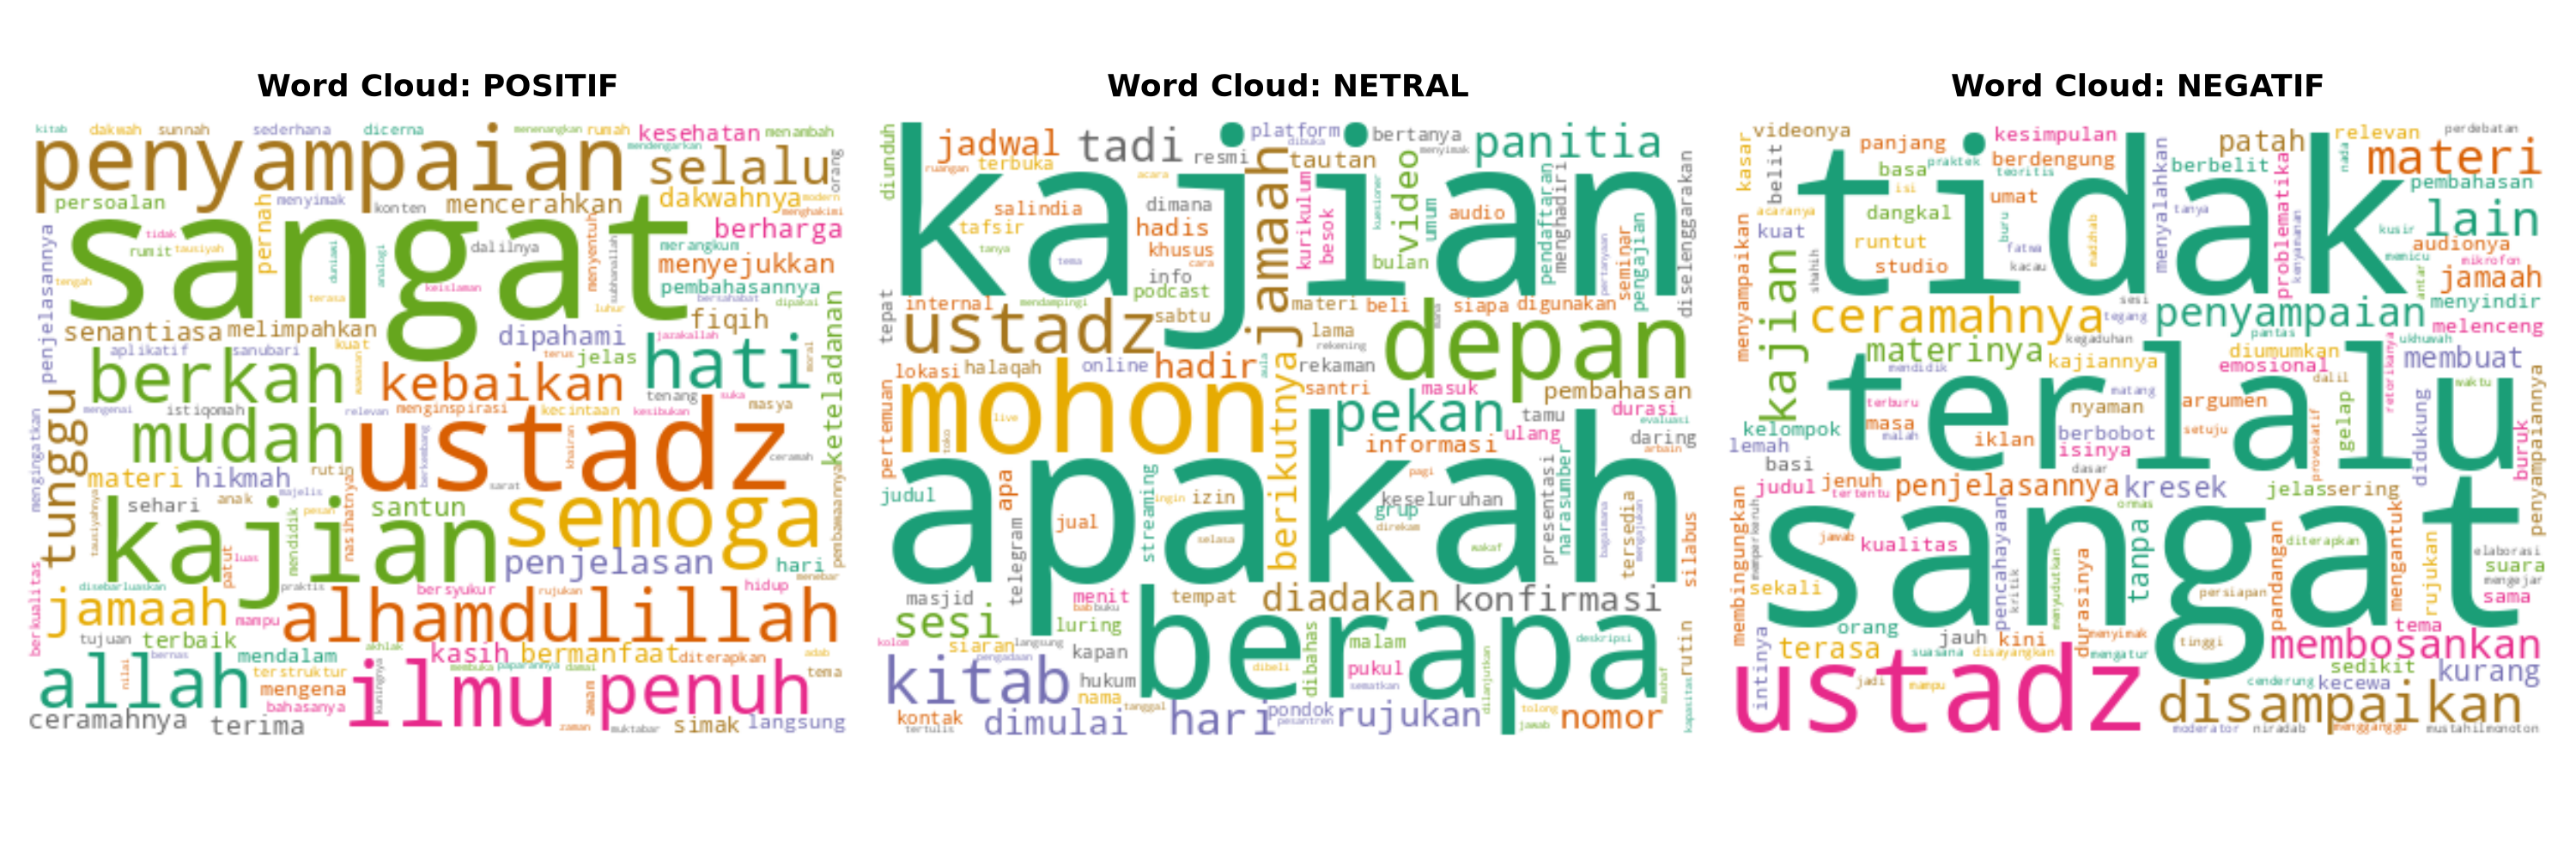

In [4]:
# Visualisasi Word Cloud per Kelas Sentimen
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (c, col_title) in enumerate(zip(['positif', 'netral', 'negatif'], ['Positif (Hijau)', 'Netral (Biru)', 'Negatif (Merah)'])):
    text_c = ' '.join(df[df['sentimen'] == c]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white', colormap='Dark2', random_state=42).generate(text_c)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Word Cloud: {c.upper()}', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Bagian 3: Feature Extraction (CountVectorizer vs TfidfVectorizer)
1. **CountVectorizer:** Menghitung frekuensi kemunculan term kata secara absolut ($TF$).
2. **TfidfVectorizer:** Mengukur bobot kepentingan kata secara relatif dengan memperhitungkan kelangkaannya di seluruh korpus ($TF \times IDF$).


In [5]:
# Train-Test Split (80% Train, 20% Test terstratifikasi)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'].values, df['sentimen'].values,
    test_size=0.20, random_state=42, stratify=df['sentimen'].values
)

count_vec = CountVectorizer()
X_tr_cnt = count_vec.fit_transform(X_train_text).toarray()
X_te_cnt = count_vec.transform(X_test_text).toarray()

tfidf_vec = TfidfVectorizer()
X_tr_tfidf = tfidf_vec.fit_transform(X_train_text).toarray()
X_te_tfidf = tfidf_vec.transform(X_test_text).toarray()

print(f"Data Training: {len(X_train_text)} sampel | Data Testing: {len(X_test_text)} sampel")
print(f"Dimensi Matriks Fitur (Kata Unik): {X_tr_cnt.shape[1]} kata")

Data Training: 60 sampel | Data Testing: 15 sampel
Dimensi Matriks Fitur (Kata Unik): 304 kata


## Bagian 4: Implementasi Naïve Bayes from Scratch & Analisis Alpha
Rumus Multinomial Naïve Bayes dengan Laplace Smoothing:
$$P(x_i | c) = \frac{N_{ci} + \alpha}{N_c + \alpha \cdot |V|}$$
di mana:
* $N_{ci}$: Frekuensi kata $i$ pada dokumen kelas $c$.
* $N_c$: Total seluruh kata pada kelas $c$.
* $|V|$: Jumlah kosakata unik (*vocabulary size*).
* $\alpha$: Parameter smoothing (*Laplace smoothing* jika $\alpha = 1$).


In [6]:
class MultinomialNBScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.prior = {}
        self.feature_prob = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        for c in self.classes:
            self.prior[c] = np.sum(y == c) / n_samples
            X_c = X[y == c]
            total_words_c = np.sum(X_c)
            word_counts_c = np.sum(X_c, axis=0)
            self.feature_prob[c] = (word_counts_c + self.alpha) / (total_words_c + self.alpha * n_features)

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                # Menghindari underflow dengan log-likelihood
                log_p = np.log(self.prior[c]) + np.sum(x * np.log(self.feature_prob[c]))
                posteriors[c] = log_p
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)

# Eksperimen Variasi Nilai Alpha
print("=== PENGARUH PARAMETER ALPHA LAPLACE SMOOTHING ===")
alphas = [0.01, 0.1, 1.0, 2.0]
for a in alphas:
    nb_s = MultinomialNBScratch(alpha=a)
    nb_s.fit(X_tr_cnt, y_train)
    p = nb_s.predict(X_te_cnt)
    acc = accuracy_score(y_test, p)
    f1 = f1_score(y_test, p, average='weighted')
    print(f"Alpha {a:4.2f} -> Accuracy: {acc*100:.2f}%, F1-Score: {f1*100:.2f}%")

=== PENGARUH PARAMETER ALPHA LAPLACE SMOOTHING ===
Alpha 0.01 -> Accuracy: 80.00%, F1-Score: 77.13%
Alpha 0.10 -> Accuracy: 80.00%, F1-Score: 77.13%
Alpha 1.00 -> Accuracy: 86.67%, F1-Score: 85.61%
Alpha 2.00 -> Accuracy: 86.67%, F1-Score: 85.61%


## Bagian 5: Model scikit-learn & Perbandingan Lengkap
Kita membandingkan varian Naive Bayes (`MultinomialNB`, `BernoulliNB`) dan Support Vector Machine dengan berbagai *kernel* (`Linear`, `RBF`, `Polynomial`) menggunakan representasi Count dan TF-IDF.


In [7]:
models = {
    'NB Scratch (alpha=1.0)': (MultinomialNBScratch(alpha=1.0), X_tr_cnt, X_te_cnt),
    'NB Multinomial (Count)': (MultinomialNB(alpha=1.0), X_tr_cnt, X_te_cnt),
    'NB Multinomial (TF-IDF)': (MultinomialNB(alpha=1.0), X_tr_tfidf, X_te_tfidf),
    'NB Bernoulli (Count)': (BernoulliNB(alpha=1.0), X_tr_cnt, X_te_cnt),
    'SVM Linear (Count)': (SVC(kernel='linear', C=1.0, random_state=42), X_tr_cnt, X_te_cnt),
    'SVM Linear (TF-IDF)': (SVC(kernel='linear', C=1.0, random_state=42), X_tr_tfidf, X_te_tfidf),
    'SVM RBF (TF-IDF)': (SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42), X_tr_tfidf, X_te_tfidf),
    'SVM Poly (TF-IDF)': (SVC(kernel='poly', degree=3, C=1.0, random_state=42), X_tr_tfidf, X_te_tfidf)
}

results = []
for name, (clf, xtr, xte) in models.items():
    clf.fit(xtr, y_train)
    pred = clf.predict(xte)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, pred, average='weighted', zero_division=0)
    results.append((name, acc, prec, rec, f1))

df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("=== TABEL PERBANDINGAN PERFORMA MODEL ===")
print(df_results.to_string(index=False))

=== TABEL PERBANDINGAN PERFORMA MODEL ===
                  Model  Accuracy  Precision   Recall  F1-Score
 NB Scratch (alpha=1.0)  0.866667   0.888889 0.866667  0.856061
 NB Multinomial (Count)  0.866667   0.888889 0.866667  0.856061
NB Multinomial (TF-IDF)  0.866667   0.888889 0.866667  0.856061
   NB Bernoulli (Count)  0.866667   0.877778 0.866667  0.865993
     SVM Linear (Count)  0.800000   0.849206 0.800000  0.771284
    SVM Linear (TF-IDF)  0.866667   0.888889 0.866667  0.856061
       SVM RBF (TF-IDF)  0.866667   0.888889 0.866667  0.856061
      SVM Poly (TF-IDF)  0.866667   0.877778 0.866667  0.865993


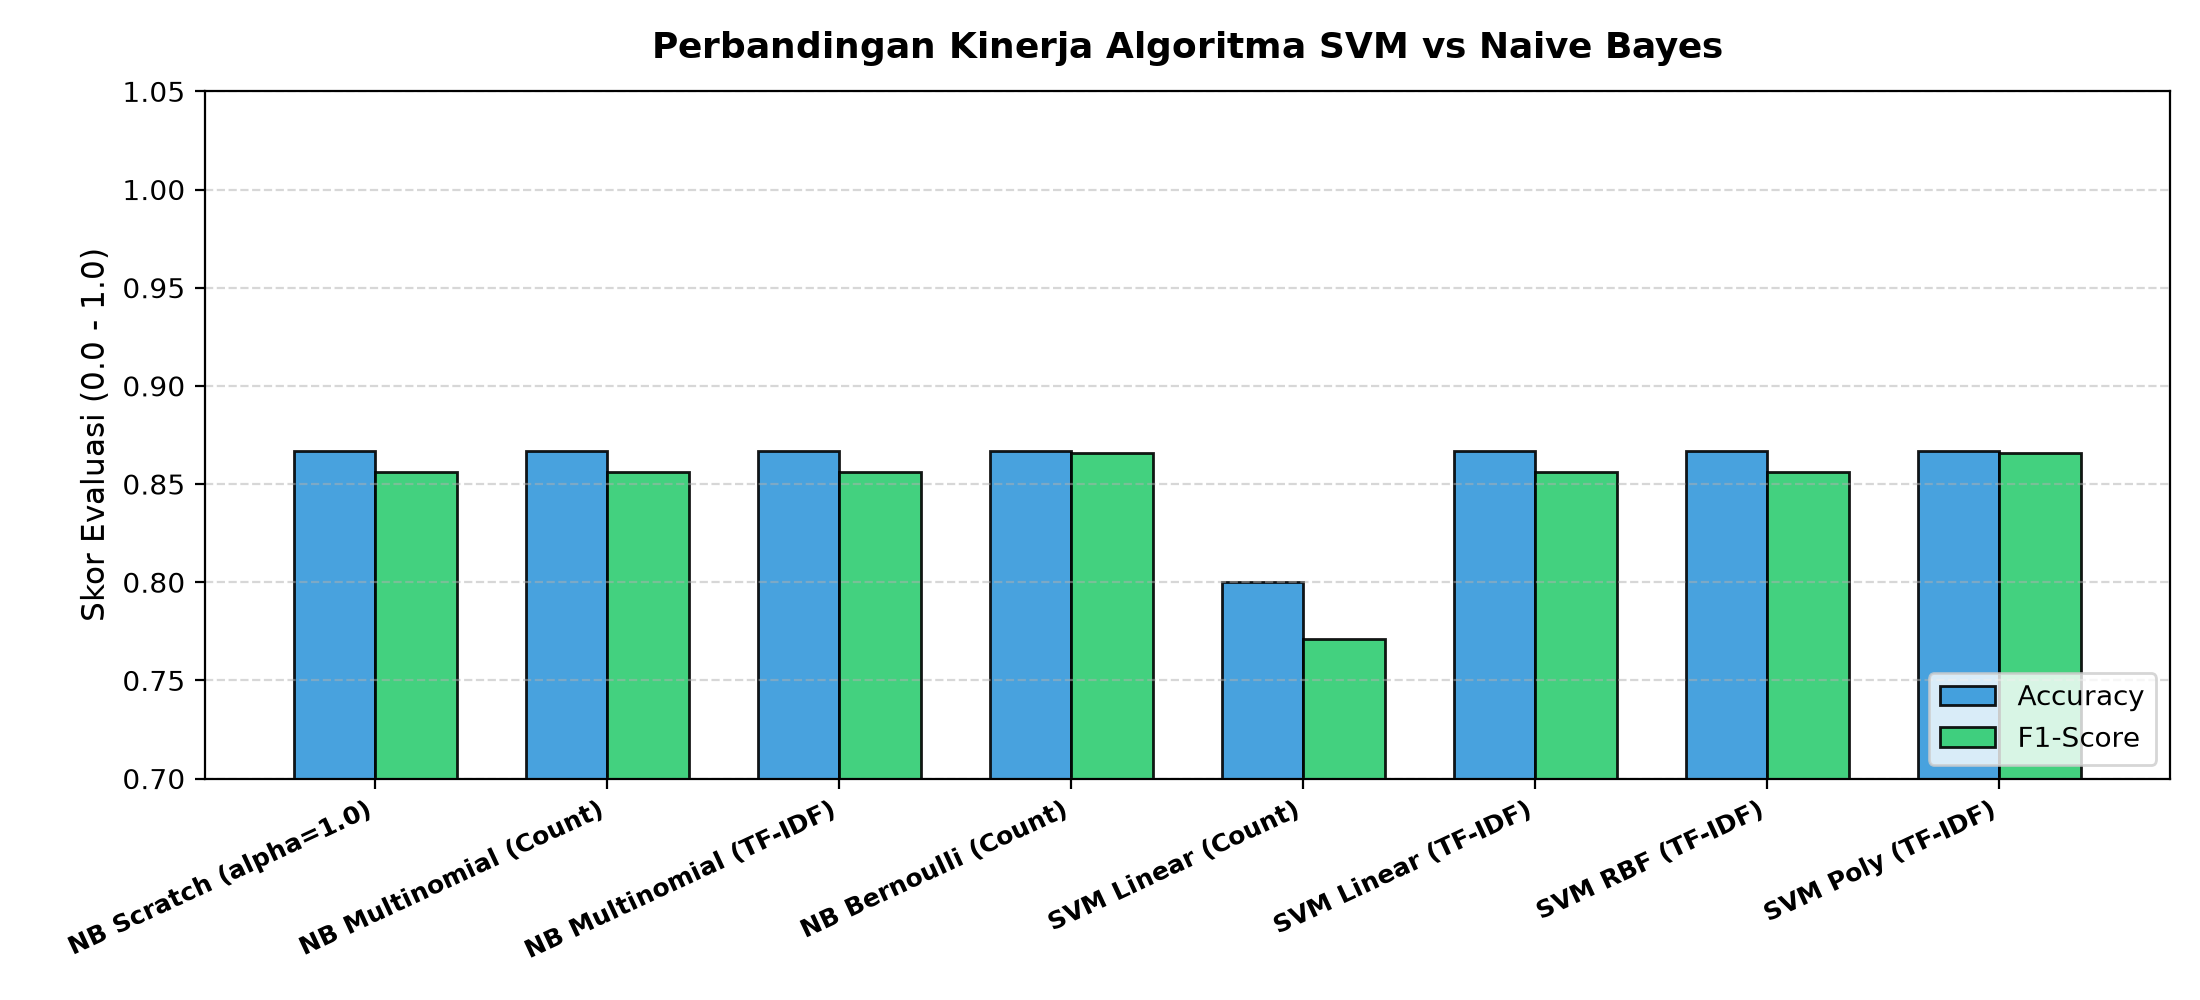

In [8]:
# Visualisasi Grafik Perbandingan Model
plt.figure(figsize=(11, 5))
x_pos = np.arange(len(df_results))
width = 0.35
plt.bar(x_pos - width/2, df_results['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='black', alpha=0.9)
plt.bar(x_pos + width/2, df_results['F1-Score'], width, label='F1-Score', color='#2ecc71', edgecolor='black', alpha=0.9)
plt.xticks(x_pos, df_results['Model'], rotation=25, ha='right', fontsize=9, fontweight='bold')
plt.ylabel('Skor Evaluasi (0.0 - 1.0)', fontsize=11)
plt.ylim(0.7, 1.05)
plt.title('Perbandingan Kinerja Algoritma SVM vs Naive Bayes', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()